In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/pollution/1pasos_mlp_pollution.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2014-07-04 08:00:00,1.107677,1.169499
2014-07-04 09:00:00,0.932123,0.910669
2014-07-04 10:00:00,0.581013,0.780643
2014-07-04 11:00:00,0.493236,0.479743
2014-07-04 12:00:00,0.570041,0.394651


In [3]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/pollution/1pasos_lstm_pollution.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2014-07-04 08:00:00,1.107677,1.002724
2014-07-04 09:00:00,0.932123,0.732394
2014-07-04 10:00:00,0.581013,0.690224
2014-07-04 11:00:00,0.493236,0.436102
2014-07-04 12:00:00,0.570041,0.498570


In [4]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/pollution/1pasos_gru_pollution.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2014-07-04 08:00:00,1.107677,1.039791
2014-07-04 09:00:00,0.932123,0.779094
2014-07-04 10:00:00,0.581013,0.719018
2014-07-04 11:00:00,0.493236,0.451223
2014-07-04 12:00:00,0.570041,0.557169


In [5]:
datosCross= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/pollution/crossformerPollution.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2014-07-04 19:00:00,0.526152,1.299997
2014-07-04 20:00:00,1.030872,0.344079
2014-07-04 21:00:00,0.789484,0.989796
2014-07-04 22:00:00,0.559069,0.687964
2014-07-04 23:00:00,0.613930,0.526496


In [6]:
datosI= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/pollution/itransformerPollution.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2014-12-01 22:20:00,0.526152,1.371187
2014-12-01 22:30:00,1.030872,0.340624
2014-12-01 22:40:00,0.789484,1.071440
2014-12-01 22:50:00,0.559069,0.750235
2014-12-01 23:00:00,0.613930,0.503929


In [7]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/pollution/tftPollution.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2014-06-29 08:00:00,-0.252872,-0.595620
2014-06-29 09:00:00,-0.603982,-0.213283
2014-06-29 10:00:00,-0.702731,-0.602483
2014-06-29 11:00:00,-0.571065,-0.688176
2014-06-29 12:00:00,-0.439399,-0.567117


In [8]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])



In [9]:
final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-06-29 08:00:00,NaN,NaN,NaN,NaN,NaN,0.342748
2014-06-29 09:00:00,NaN,NaN,NaN,NaN,NaN,-0.390698
2014-06-29 10:00:00,NaN,NaN,NaN,NaN,NaN,-0.100248
2014-06-29 11:00:00,NaN,NaN,NaN,NaN,NaN,0.117111
2014-06-29 12:00:00,NaN,NaN,NaN,NaN,NaN,0.127718


In [10]:
final = final.dropna()
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-12-01 23:00:00,-0.165950,-0.066217,-0.087843,-0.007838,0.110001,-0.088513
2014-12-02 00:00:00,-0.083239,0.033480,0.015223,0.135260,0.011352,-0.000546
2014-12-02 01:00:00,-0.155907,-0.053572,-0.071558,0.004658,0.247164,-0.052555
2014-12-02 02:00:00,-0.109024,-0.021650,-0.030990,0.092457,0.064242,-0.026759
2014-12-02 03:00:00,-0.057224,-0.049918,-0.114587,0.044500,0.185592,-0.051290


Muestra aleatoria

In [11]:
final = final.sample(frac=0.10, random_state=42)

In [12]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [13]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print(p)


5.765396714489761e-10


In [14]:
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print(p)


2.578269225634358e-10


In [15]:
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print(p)


2.1728441410330216e-09


In [16]:
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print(p)


3.223483029145002e-11


In [17]:
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print(p)


1.930131845638695e-11


In [18]:
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print(p)


5.342776387912538e-10


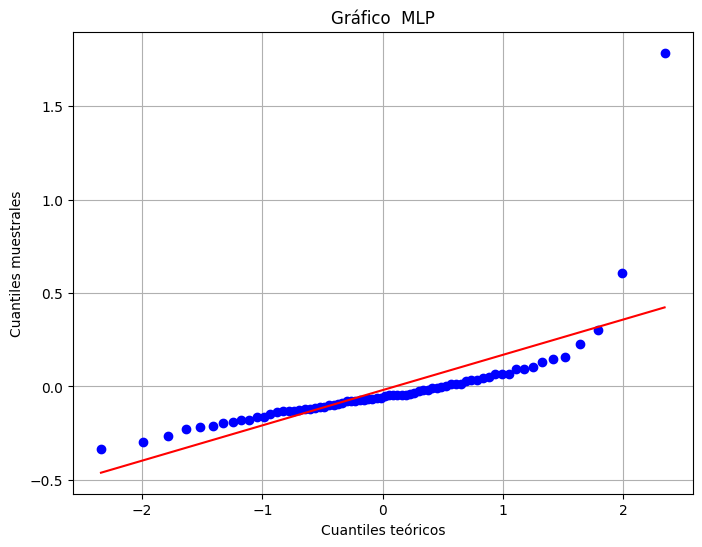

In [19]:
plt.figure(figsize=(8, 6))

stats.probplot(final["MLP"], dist="norm", plot=plt)
plt.title('Gráfico  MLP')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

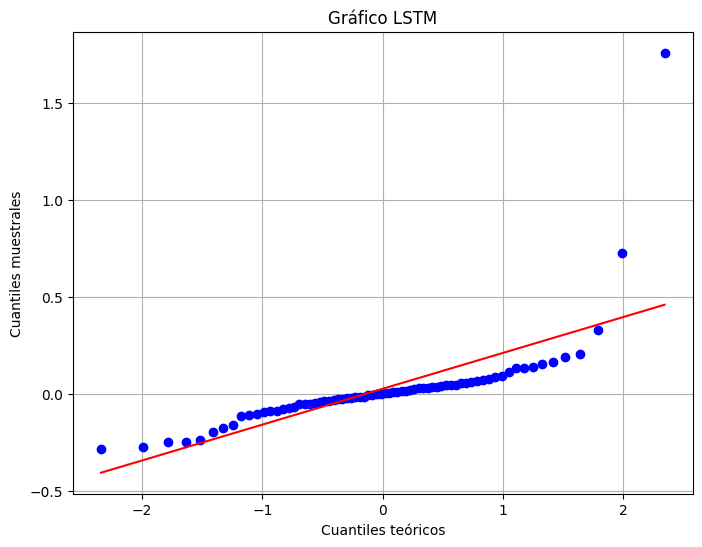

In [20]:
plt.figure(figsize=(8, 6))

stats.probplot(final["LSTM"], dist="norm", plot=plt)
plt.title('Gráfico LSTM')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

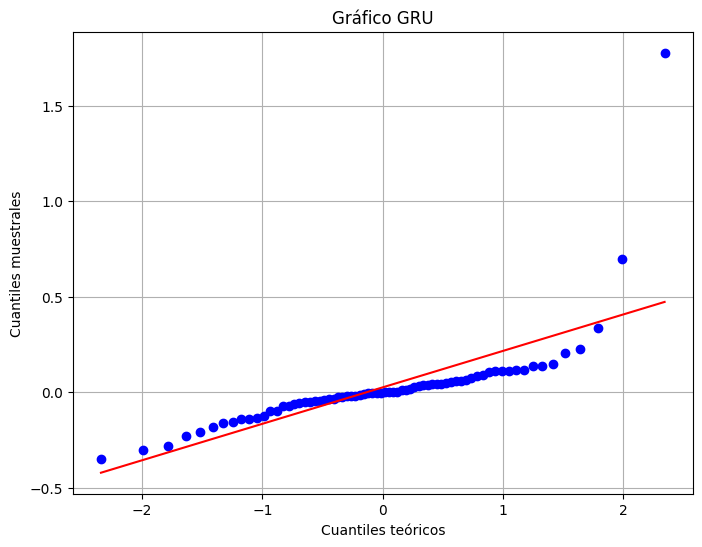

In [21]:
plt.figure(figsize=(8, 6))

stats.probplot(final["GRU"], dist="norm", plot=plt)
plt.title('Gráfico GRU')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

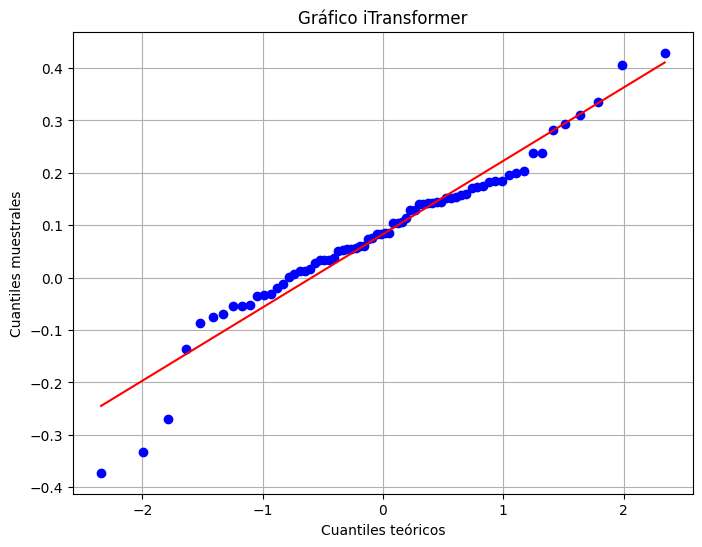

In [22]:
plt.figure(figsize=(8, 6))

stats.probplot(final["iTransformer"], dist="norm", plot=plt)
plt.title('Gráfico iTransformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

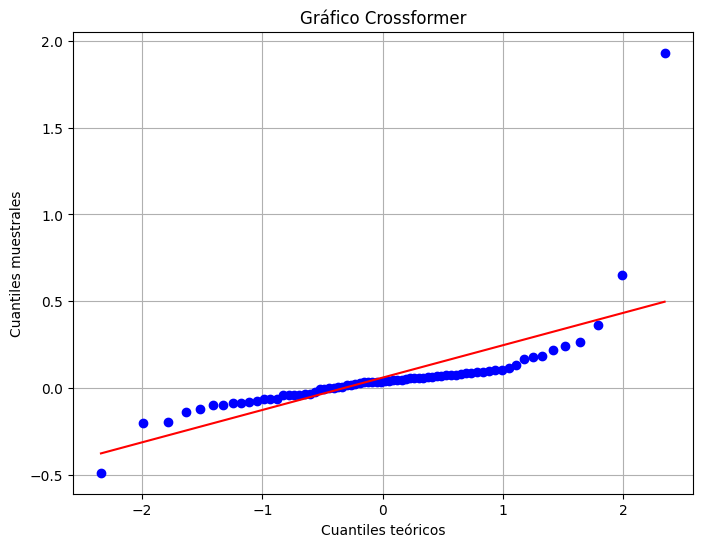

In [23]:
plt.figure(figsize=(8, 6))

stats.probplot(final["Crossformer"], dist="norm", plot=plt)
plt.title('Gráfico Crossformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

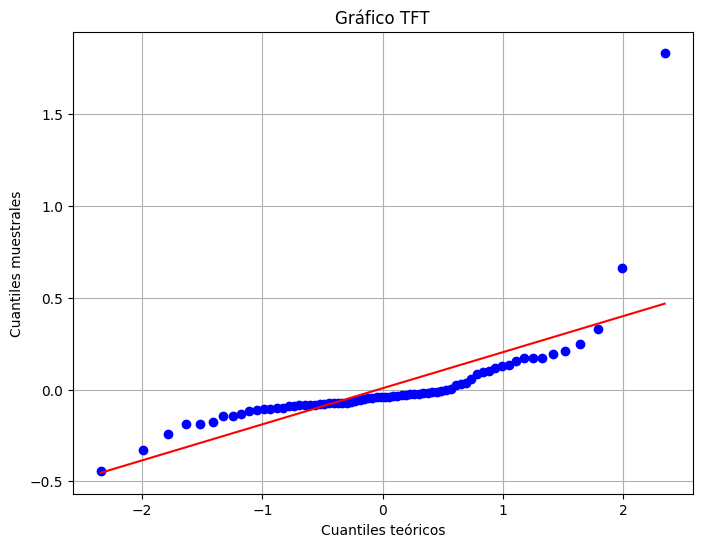

In [24]:
plt.figure(figsize=(8, 6))

stats.probplot(final["TFT"], dist="norm", plot=plt)
plt.title('Gráfico TFT')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

In [25]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

4.995639138996405e-17


In [26]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.00000,0.00005,0.00004
1,MLP vs GRU,0.00000,0.00002,0.00001
2,MLP vs Crossformer,0.00000,0.00000,0.00000
3,MLP vs iTransformer,0.00000,0.00005,0.00004
4,MLP vs TFT,0.00707,0.10602,0.03303
5,LSTM vs GRU,0.43869,1.00000,0.43869
6,LSTM vs Crossformer,0.00661,0.09910,0.03303
7,LSTM vs iTransformer,0.00050,0.00754,0.00402
8,LSTM vs TFT,0.00091,0.01367,0.00638
9,GRU vs Crossformer,0.00254,0.03803,0.01521
